In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [4]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 1. 生成模拟店铺商品数据（120个商品）
np.random.seed(42)
n_products = 120

# 商品ID
product_id = [f"P{1000+i}" for i in range(n_products)]

# 商品标题（
title_length = np.random.randint(15, 80, n_products)

# 价格
price = np.random.uniform(2, 80, n_products)
price = np.round(price, 2)

# 销量（过去30天）
sales = np.random.poisson(lam=50, size=n_products)
sales = np.where(sales > 300, 300, sales)  # 上限300

# 库存量
stock = np.random.randint(0, 500, n_products)

# 评价数量
review_count = np.random.poisson(lam=sales*0.3, size=n_products)

# 评分（1-5星）
rating = np.random.uniform(3.2, 5.0, n_products)
rating = np.round(rating, 1)

# 类目（模拟3个类目）
category = np.random.choice(['手机配件', '女装', '家居生活'], size=n_products, p=[0.4, 0.35, 0.25])

# 上架天数（模拟）
days_listed = np.random.randint(7, 180, n_products)

# 是否为促销商品
is_promo = np.random.choice([0,1], size=n_products, p=[0.7,0.3])

# 构建DataFrame
df = pd.DataFrame({
    'product_id': product_id,
    'category': category,
    'price_usd': price,
    'sales_30d': sales,
    'stock': stock,
    'review_count': review_count,
    'rating': rating,
    'title_length': title_length,
    'days_listed': days_listed,
    'is_promo': is_promo
})

# 添加计算字段：销售额贡献 GMV
df['gmv'] = df['price_usd'] * df['sales_30d']

# 添加价格分层
df['price_tier'] = pd.cut(df['price_usd'], bins=[0, 10, 25, 50, 200], labels=['低价(≤10)', '中低价(10-25)', '中高价(25-50)', '高价(>50)'])

print("数据预览：")
df.head()

数据预览：


,product_id,category,price_usd,sales_30d,stock,review_count,rating,title_length,days_listed,is_promo,gmv,price_tier
0,P1000,家居生活,65.03,50,347,11,3.6,66,87,1,3251.50,高价(>50)
1,P1001,手机配件,51.41,55,94,16,3.7,29,120,0,2827.55,高价(>50)
2,P1002,女装,69.97,47,71,16,4.8,75,46,0,3288.59,高价(>50)
3,P1003,家居生活,64.69,63,38,10,3.2,35,51,0,4075.47,高价(>50)
4,P1004,手机配件,16.55,59,153,13,3.4,38,68,1,976.45,中低价(10-25)


In [7]:
# 2. 数据质量检查
print("缺失值统计：")
print(df.isnull().sum())
print("\n描述统计：")
df.describe()

缺失值统计：
product_id      0
category        0
price_usd       0
sales_30d       0
stock           0
review_count    0
rating          0
title_length    0
days_listed     0
is_promo        0
gmv             0
price_tier      0
dtype: int64

描述统计：


,price_usd,sales_30d,stock,review_count,rating,title_length,days_listed,is_promo,gmv
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,41.138500,50.791667,246.800000,15.208333,4.064167,47.183333,87.483333,0.283333,2075.491333
std,22.518671,7.179448,138.665767,4.540936,0.519986,20.564301,50.386070,0.452506,1164.710662
min,2.390000,33.000000,0.000000,6.000000,3.200000,15.000000,8.000000,0.000000,108.800000
25%,20.875000,46.000000,124.000000,12.000000,3.600000,28.750000,44.500000,0.000000,1044.930000
50%,42.890000,51.000000,249.500000,15.000000,4.100000,48.500000,86.500000,0.000000,2151.420000
75%,59.157500,55.250000,361.750000,18.000000,4.500000,65.250000,125.250000,1.000000,2977.097500
max,78.880000,72.000000,481.000000,33.000000,5.000000,79.000000,176.000000,1.000000,4447.800000


In [8]:
# 3. 整体店铺关键指标
total_gmv = df['gmv'].sum()
total_sales = df['sales_30d'].sum()
avg_price = df['price_usd'].mean()
avg_review = df['review_count'].mean()

print(f"店铺月度GMV: ${total_gmv:,.0f}")
print(f"月度总销量: {total_sales} 件")
print(f"平均售价: ${avg_price:.2f}")
print(f"平均评价数: {avg_review:.0f}")

店铺月度GMV: $249,059
月度总销量: 6095 件
平均售价: $41.14
平均评价数: 15


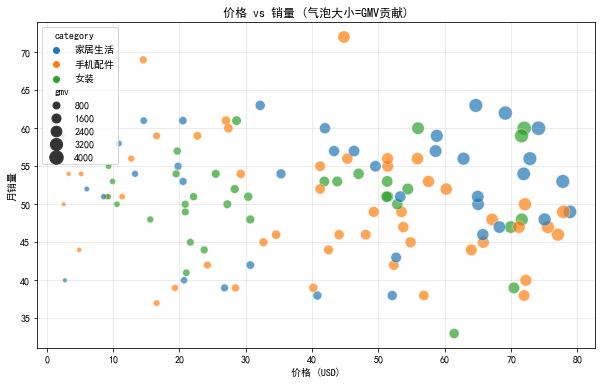

In [9]:
# 4. 价格-销量关系分析
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='price_usd', y='sales_30d', hue='category', size='gmv', sizes=(20,200), alpha=0.7)
plt.title('价格 vs 销量 (气泡大小=GMV贡献)')
plt.xlabel('价格 (USD)')
plt.ylabel('月销量')
plt.grid(True, alpha=0.3)
plt.show()


In [10]:
# 5. 找出引流款和利润款
# 引流款：销量前20% 且 价格低于中位数
threshold_sales = df['sales_30d'].quantile(0.8)
median_price = df['price_usd'].median()
traffic_products = df[(df['sales_30d'] >= threshold_sales) & (df['price_usd'] < median_price)]

# 利润款：GMV前20% 且 价格高于中位数
threshold_gmv = df['gmv'].quantile(0.8)
profit_products = df[(df['gmv'] >= threshold_gmv) & (df['price_usd'] > median_price)]

print(f"引流款数量: {len(traffic_products)}")
print(traffic_products[['product_id','category','price_usd','sales_30d','gmv']].head())

print(f"\n利润款数量: {len(profit_products)}")
print(profit_products[['product_id','category','price_usd','sales_30d','gmv']].head())

引流款数量: 13
   product_id category  price_usd  sales_30d      gmv
4       P1004     手机配件      16.55         59   976.45
53      P1053     手机配件      27.02         61  1648.22
59      P1059     家居生活      41.94         60  2516.40
60      P1060       女装      19.67         57  1121.19
64      P1064     家居生活      32.17         63  2026.71

利润款数量: 24
  product_id category  price_usd  sales_30d      gmv
0      P1000     家居生活      65.03         50  3251.50
2      P1002       女装      69.97         47  3288.59
3      P1003     家居生活      64.69         63  4075.47
5      P1005       女装      71.62         48  3437.76
7      P1007     家居生活      64.98         51  3313.98


In [11]:
# 6. 滞销品分析（销量为0或很低，库存积压）
dead_stock = df[(df['sales_30d'] < 5) & (df['stock'] > 50)]
print(f"滞销积压商品数: {len(dead_stock)}")
dead_stock[['product_id','category','price_usd','sales_30d','stock']]

滞销积压商品数: 0


,product_id,category,price_usd,sales_30d,stock


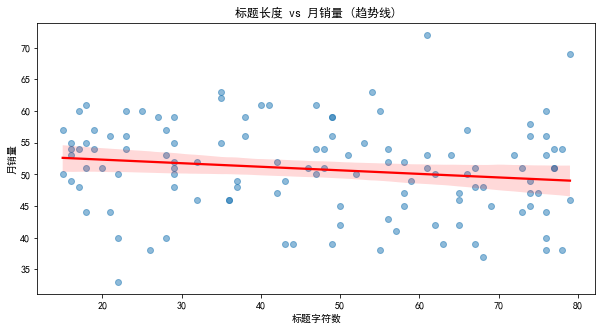

In [12]:
# 7. 标题长度与销量的关系（关键词优化机会）
plt.figure(figsize=(10,5))
sns.regplot(data=df, x='title_length', y='sales_30d', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('标题长度 vs 月销量 (趋势线)')
plt.xlabel('标题字符数')
plt.ylabel('月销量')
plt.show()

In [13]:
# 找出标题过短（<30字符）且销量低于平均的商品
avg_sales = df['sales_30d'].mean()
short_title_poor = df[(df['title_length'] < 30) & (df['sales_30d'] < avg_sales)]
print(f"标题过短且销量不佳的商品数量: {len(short_title_poor)}")

标题过短且销量不佳的商品数量: 12


In [14]:
# 8. 类目表现对比
category_perf = df.groupby('category').agg({
    'gmv': 'sum',
    'sales_30d': 'sum',
    'product_id': 'count',
    'price_usd': 'mean'
}).rename(columns={'product_id':'product_count'}).round(2)
category_perf['avg_gmv_per_product'] = category_perf['gmv'] / category_perf['product_count']
category_perf


,gmv,sales_30d,product_count,price_usd,avg_gmv_per_product
category,,,,,
女装,63914.25,1727,34,37.10,1879.830882
家居生活,88112.58,1992,38,44.04,2318.752105
手机配件,97032.13,2376,48,41.70,2021.502708


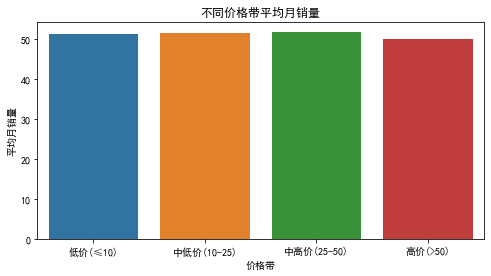

In [17]:
# 9. 定价策略优化建议（基于价格分层的销量分布）
price_tier_perf = df.groupby('price_tier').agg({
    'sales_30d': 'sum',
    'gmv': 'sum',
    'product_id': 'count'
}).rename(columns={'product_id':'count'})
price_tier_perf['avg_sales_per_product'] = price_tier_perf['sales_30d'] / price_tier_perf['count']
price_tier_perf


# 可视化
plt.figure(figsize=(8,4))
# 旧版本使用 ci=None 或不使用 errorbar
sns.barplot(data=df, x='price_tier', y='sales_30d', ci=None, order=['低价(≤10)', '中低价(10-25)', '中高价(25-50)', '高价(>50)'])
plt.title('不同价格带平均月销量')
plt.xlabel('价格带')
plt.ylabel('平均月销量')
plt.show()

In [19]:
report = """
# 店铺诊断与优化建议报告

## 一、店铺整体表现
- 月度GMV: ${:.0f}
- 月总销量: {} 件
- 平均售价: ${:.2f}
- 滞销积压商品: {} 个

## 二、主要问题
1. **引流款不足**：当前引流款数量为 {}，占店铺商品总数 {}% ，导致流量天花板较低。
2. **利润款转化弱**：利润款仅 {} 个，且部分高价商品销量偏低。
3. **标题长度影响销量**：趋势线显示标题长度在 40-60 字符区间销量较优，有 {} 个标题过短的商品销量低于平均。
4. **库存积压**：{} 个商品月销量<5且库存>50，占用资金。

## 三、优化建议
1. **打造引流款**：从现有低价商品中选出3-5个潜力品，降价至$9.9以下并加大广告预算，换取销量和排名。
2. **利润款组合销售**：将利润款与引流款捆绑（如买手机壳送支架），提升客单价。
3. **标题优化**：对标题<30字符的商品，按照“核心词+属性词+场景词+长尾词”重构标题，目标长度50字符左右。
4. **清仓滞销品**：对积压库存>100且销量为0的商品，进行折扣清仓（买一送一或捆绑），回笼资金。
5. **类目策略**：{} 类目贡献GMV占比最高，应增加该品类新品；{} 类目单品产值低，需精简SKU。

""".format(
    total_gmv, total_sales, avg_price, len(dead_stock),
    len(traffic_products), round(len(traffic_products)/n_products*100,1),
    len(profit_products),
    len(short_title_poor),
    len(dead_stock),
    category_perf['gmv'].idxmax(), category_perf['gmv'].idxmin()
)

print(report)

# 可选：保存报告为txt文件
with open('店铺诊断报告.txt', 'w', encoding='utf-8') as f:
    f.write(report)

# %% [code]
# 11. 导出清洗后的数据供PowerBI / Excel使用
df.to_csv('shop_data_cleaned.csv', index=False, encoding='utf-8-sig')
print("数据已导出为 shop_data_cleaned.csv")


# 店铺诊断与优化建议报告

## 一、店铺整体表现
- 月度GMV: $249059
- 月总销量: 6095 件
- 平均售价: $41.14
- 滞销积压商品: 0 个

## 二、主要问题
1. **引流款不足**：当前引流款数量为 13，占店铺商品总数 10.8% ，导致流量天花板较低。
2. **利润款转化弱**：利润款仅 24 个，且部分高价商品销量偏低。
3. **标题长度影响销量**：趋势线显示标题长度在 40-60 字符区间销量较优，有 12 个标题过短的商品销量低于平均。
4. **库存积压**：0 个商品月销量<5且库存>50，占用资金。

## 三、优化建议
1. **打造引流款**：从现有低价商品中选出3-5个潜力品，降价至$9.9以下并加大广告预算，换取销量和排名。
2. **利润款组合销售**：将利润款与引流款捆绑（如买手机壳送支架），提升客单价。
3. **标题优化**：对标题<30字符的商品，按照“核心词+属性词+场景词+长尾词”重构标题，目标长度50字符左右。
4. **清仓滞销品**：对积压库存>100且销量为0的商品，进行折扣清仓（买一送一或捆绑），回笼资金。
5. **类目策略**：手机配件 类目贡献GMV占比最高，应增加该品类新品；女装 类目单品产值低，需精简SKU。


数据已导出为 shop_data_cleaned.csv
